# Brazilian Credit Derivatives — End-to-End Calibration

**From market quotes to CLN and TRS pricing in 6 steps:**

1. Build CDI discount curve from DI futures
2. Price NTN-F bonds → extract market yields
3. Infer hazard rates from bond prices (bond-implied CDS)
4. Build survival/CDS curve
5. Price a Credit-Linked Note (CLN) on a Brazilian corporate
6. Price a Total Return Swap (TRS) on the bond

All using BUS/252, São Paulo calendar, CDI compounding.

In [1]:
import sys; sys.path.insert(0, "..")
import math, numpy as np, matplotlib.pyplot as plt
from datetime import date
from dateutil.relativedelta import relativedelta

from pricebook.viz import configure_theme
from pricebook.core.day_count import DayCountConvention, year_fraction
from pricebook.core.discount_curve import DiscountCurve
from pricebook.core.survival_curve import SurvivalCurve
from pricebook.fixed_income.brazilian import (
    synthetic_di_strip, build_cdi_curve_from_di, DIFuture, DISwap, LFTBond,
    _bus_days, _di_discount_factor, _di_rate_from_df, cupom_cambial,
)
from pricebook.fixed_income.sovereign_bonds import create_sovereign_bond, create_sovereign_zero
from pricebook.credit.cds import CDS
from pricebook.credit.cln import CreditLinkedNote
from pricebook.credit.cds_bond_basis import bond_implied_cds_spread
from pricebook.equity.trs import TotalReturnSwap

configure_theme(dark=False)
REF = date(2024, 6, 3)
print("Setup complete — REF:", REF)

Setup complete — REF: 2024-06-03


## Step 1: CDI Discount Curve from DI Futures

DI futures are the primary curve instruments in Brazil. Each contract pays 100,000 at maturity, quoted as an annualised rate:

$$PU = \frac{100{,}000}{(1 + DI)^{bd/252}}$$

where $bd$ = business days to maturity (São Paulo calendar).

In [2]:
# Generate realistic DI futures strip (Selic at 10.50%, upward sloping)
di_strip = synthetic_di_strip(REF, selic=0.1050, n_contracts=15, slope_bp_per_year=30)

# Build CDI discount curve
cdi_curve = build_cdi_curve_from_di(REF, di_strip)

print(f"{'Maturity':<14s} {'DI Rate':<10s} {'Bus Days':<10s} {'DF':<12s} {'PU':<12s}")
print("-" * 58)
for c in di_strip:
    df = cdi_curve.df(c["maturity"])
    print(f"{str(c['maturity']):<14s} {c['rate']*100:>7.2f}%   {c['bus_days']:>5d}     {df:>10.6f}  {c['pu']:>10.2f}")

Maturity       DI Rate    Bus Days   DF           PU          
----------------------------------------------------------
2024-08-01       10.55%      43       0.983030    98302.95
2024-10-01       10.60%      86       0.966194    96619.44
2024-12-02       10.65%     129       0.949498    94949.76
2025-02-03       10.70%     172       0.932942    93294.22
2025-04-01       10.75%     211       0.918051    91805.14
2025-06-02       10.80%     252       0.902527    90252.71
2025-08-01       10.85%     295       0.886391    88639.11
2025-10-01       10.90%     338       0.870407    87040.66
2025-12-01       10.95%     381       0.854576    85457.60
2026-02-02       11.00%     424       0.838901    83890.14
2026-04-01       11.05%     464       0.824462    82446.25
2026-06-01       11.10%     504       0.810162    81016.20
2026-08-03       11.15%     548       0.794593    79459.33
2026-10-01       11.20%     590       0.779892    77989.20
2026-12-01       11.25%     631       0.765693    76

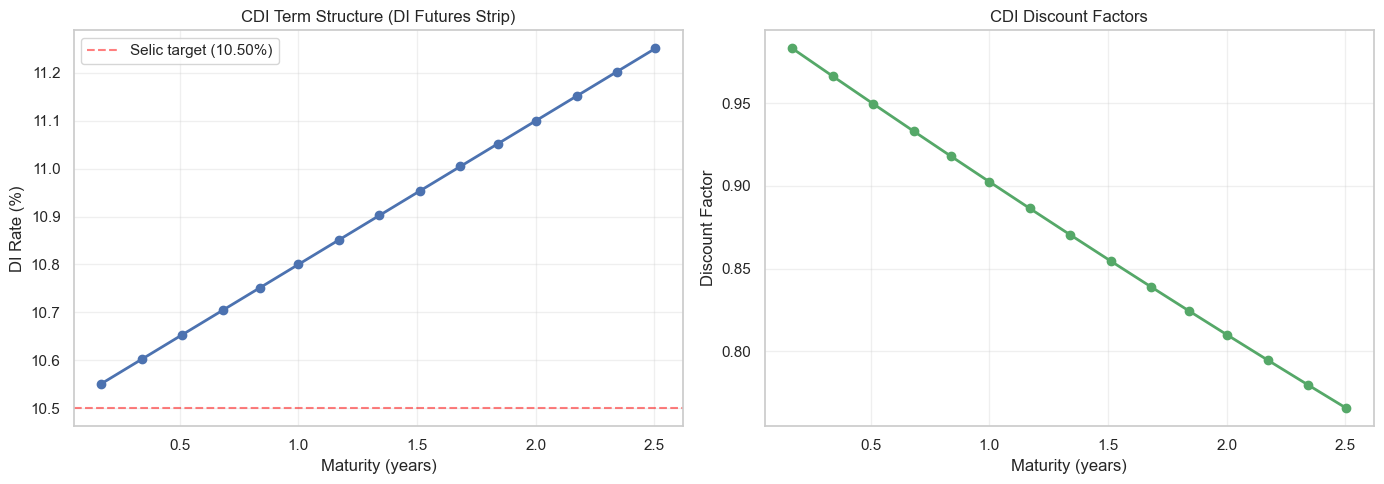

In [4]:
# Plot CDI term structure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
years = [c["years"] for c in di_strip]
rates = [c["rate"] * 100 for c in di_strip]
dfs = [cdi_curve.df(c["maturity"]) for c in di_strip]
    
ax1.plot(years, rates, 'b-o', linewidth=2, markersize=6)
ax1.set_xlabel('Maturity (years)'); ax1.set_ylabel('DI Rate (%)')
ax1.set_title('CDI Term Structure (DI Futures Strip)')
ax1.axhline(y=10.50, color='red', linestyle='--', alpha=0.5, label='Selic target (10.50%)')
ax1.legend(); ax1.grid(True, alpha=0.3)
    
ax2.plot(years, dfs, 'g-o', linewidth=2, markersize=6)
ax2.set_xlabel('Maturity (years)'); ax2.set_ylabel('Discount Factor')
ax2.set_title('CDI Discount Factors')
ax2.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.savefig('brazilian_cdi_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2: NTN-F and LTN Pricing

**NTN-F** (fixed coupon, 10%): semi-annual coupons, BUS/252, face R$ 1,000

$$P = \sum_i \frac{c}{(1+y)^{bd_i/252}} + \frac{1000}{(1+y)^{bd_n/252}}$$

**LTN** (zero-coupon): discount bond, face R$ 1,000

$$P = \frac{1000}{(1+y)^{bd/252}}$$

In [5]:
# Price NTN-F bonds at different maturities
maturities = [2, 3, 5, 7, 10]
ntn_f_prices = {}
print(f"{'NTN-F 10%':<15s} {'Dirty Price':<14s} {'Yield*':<10s}")
print("-" * 39)
for T in maturities:
    mat = date(2024 + T, 1, 1)
    bond = create_sovereign_bond("NTN_F", REF, mat, 0.10)
    price = bond.dirty_price(cdi_curve)
    ntn_f_prices[T] = price
    # Approximate yield
    bd = _bus_days(REF, mat)
    implied_y = _di_rate_from_df(price / 100, bd) if price > 0 else 0
    print(f"  {T}Y maturity  {price:>10.2f}     {implied_y*100:>6.2f}%")

# LTN zero-coupon
print(f"\n{'LTN':<15s} {'Price':<14s} {'Yield':<10s}")
print("-" * 39)
for T in [1, 2, 3, 5]:
    mat = date(2024 + T, 1, 1)
    ltn = create_sovereign_zero("LTN", REF, mat)
    price = ltn.price(cdi_curve)
    bd = _bus_days(REF, mat)
    y = _di_rate_from_df(price / 100, bd)
    print(f"  {T}Y maturity  {price:>10.2f}     {y*100:>6.2f}%")

NTN-F 10%       Dirty Price    Yield*    
---------------------------------------
  2Y maturity       99.07       0.59%
  3Y maturity       97.97       0.80%
  5Y maturity       95.84       0.93%
  7Y maturity       94.13       0.92%
  10Y maturity       92.19       0.85%

LTN             Price          Yield     
---------------------------------------
  1Y maturity       94.18      10.68%
  2Y maturity       84.69      10.98%
  3Y maturity       75.85      11.27%
  5Y maturity       60.62      11.57%


## Step 3: Infer Hazard Rates from Bond Prices

Given a risky bond price and a risk-free curve, we solve for the flat hazard rate $h$ such that:

$$P^{risky}(h) = P^{market}$$

Then the implied CDS spread is $S = (1-R) \times h$.

This is the **bond-implied CDS spread** (Zhou 2008).

In [6]:
# Simulate "risky" corporate bond prices (NTN-F equivalent with credit spread)
# Corporate bond trades at a discount to sovereign → implies credit risk
corporate_discounts = {2: 2.0, 3: 3.5, 5: 5.0, 7: 6.5, 10: 8.0}  # points below sovereign

print(f"{'Tenor':<8s} {'Sovereign':<12s} {'Corporate':<12s} {'Implied CDS':<14s} {'Hazard':<10s}")
print("-" * 56)

implied_hazards = {}
for T in [2, 3, 5, 7, 10]:
    sov_price = ntn_f_prices[T]
    corp_price = sov_price - corporate_discounts[T]
    
    # Average DI rate for this maturity
    bd = _bus_days(REF, date(2024 + T, 1, 1))
    avg_di = _di_rate_from_df(cdi_curve.df(date(2024 + T, 1, 1)), bd)
    
    result = bond_implied_cds_spread(0.10, corp_price, float(T), avg_di, recovery=0.40)
    implied_hazards[T] = result["hazard_rate"]
    print(f"  {T}Y    {sov_price:>8.2f}    {corp_price:>8.2f}    {result['cds_spread']*10000:>8.0f} bp    {result['hazard_rate']*100:>6.2f}%")

Tenor    Sovereign    Corporate    Implied CDS    Hazard    
--------------------------------------------------------
  2Y       99.07       97.07          38 bp      0.63%
  3Y       97.97       94.47          63 bp      1.05%
  5Y       95.84       90.84          59 bp      0.98%
  7Y       94.13       87.63          67 bp      1.12%
  10Y       92.19       84.19          73 bp      1.22%


## Step 4: Build Survival Curve and Price CDS

From the implied hazard rates at each tenor, we build a piecewise-flat survival curve:

$$Q(T) = e^{-h \times T}$$

Then price a par CDS using the standard premium = protection condition.

In [7]:
# Build survival curve from implied hazards (use 5Y as reference)
h_5y = implied_hazards.get(5, 0.02)
surv_dates = [REF + relativedelta(years=i) for i in range(1, 11)]
surv_probs = [math.exp(-h_5y * i) for i in range(1, 11)]
surv_curve = SurvivalCurve(REF, surv_dates, surv_probs)

# Price CDS at different tenors
print(f"{'CDS':<8s} {'Par Spread':<14s} {'Survival':<12s}")
print("-" * 34)
for T in [1, 3, 5, 7, 10]:
    mat = REF + relativedelta(years=T)
    cds = CDS(REF, mat, 0.01, recovery=0.40)  # dummy spread
    par = cds.par_spread(cdi_curve, surv_curve)
    q = surv_curve.survival(mat)
    print(f"  {T}Y    {par*10000:>8.0f} bp    {q*100:>8.1f}%")

CDS      Par Spread     Survival    
----------------------------------
  1Y          59 bp        99.0%
  3Y          59 bp        97.1%
  5Y          59 bp        95.2%
  7Y          59 bp        93.4%
  10Y          59 bp        90.7%


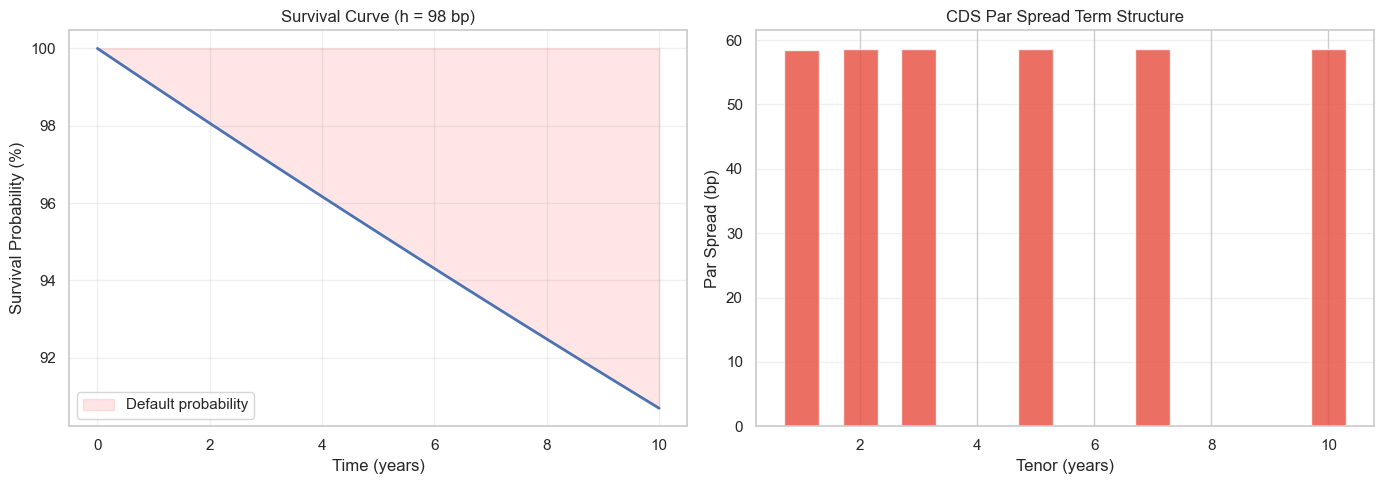

In [9]:
# Plot survival curve + CDS term structure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
times = np.linspace(0, 10, 100)
survs = [math.exp(-h_5y * t) * 100 for t in times]
    
ax1.plot(times, survs, 'b-', linewidth=2)
ax1.fill_between(times, survs, 100, alpha=0.1, color='red', label='Default probability')
ax1.set_xlabel('Time (years)'); ax1.set_ylabel('Survival Probability (%)')
ax1.set_title(f'Survival Curve (h = {h_5y*10000:.0f} bp)')
ax1.legend(); ax1.grid(True, alpha=0.3)
    
tenors = [1, 2, 3, 5, 7, 10]
spreads = []
for T in tenors:
    mat = REF + relativedelta(years=T)
    cds = CDS(REF, mat, 0.01, recovery=0.40)
    spreads.append(cds.par_spread(cdi_curve, surv_curve) * 10000)
    
ax2.bar(tenors, spreads, width=0.6, color='#e74c3c', alpha=0.8)
ax2.set_xlabel('Tenor (years)'); ax2.set_ylabel('Par Spread (bp)')
ax2.set_title('CDS Par Spread Term Structure')
ax2.grid(True, alpha=0.3, axis='y')
    
plt.tight_layout()
plt.savefig('brazilian_credit_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Price a Credit-Linked Note (CLN)

A CLN is a funded credit exposure — the investor buys a bond that pays coupon + principal conditional on no default. On default, the investor receives recovery × notional.

$$PV^{CLN} = \sum_i c \cdot \alpha_i \cdot D(t_i) \cdot Q(t_i) + N \cdot D(T) \cdot Q(T) + R \cdot N \cdot \sum_i D(t_i) \cdot \Delta PD_i$$

In [10]:
# Price CLN on Brazilian corporate
from pricebook.core.schedule import Frequency

cln = CreditLinkedNote(
    start=REF, end=REF + relativedelta(years=5),
    coupon_rate=0.12,  # CDI + 150bp ≈ 12% (typical BRL corporate CLN)
    notional=1_000_000,
    recovery=0.40,
    frequency=Frequency.SEMI_ANNUAL,
    day_count=DayCountConvention.BUS_252,
)

# Price with and without credit risk
cln_risky = cln.dirty_price(cdi_curve, surv_curve)
rf_dates = [REF + relativedelta(years=i) for i in range(1, 11)]
rf_surv = SurvivalCurve(REF, rf_dates, [1.0] * 10)
cln_riskfree = cln.dirty_price(cdi_curve, rf_surv)

credit_discount = (1 - cln_risky / cln_riskfree) * 100

print(f"CLN 5Y, 12% coupon, R$ 1M notional:")
print(f"  Risk-free PV:  R$ {cln_riskfree:>12,.0f}")
print(f"  Risky PV:      R$ {cln_risky:>12,.0f}")
print(f"  Credit discount: {credit_discount:.1f}%")
print(f"  Credit charge: R$ {cln_riskfree - cln_risky:>12,.0f}")

CLN 5Y, 12% coupon, R$ 1M notional:
  Risk-free PV:  R$    1,029,312
  Risky PV:      R$    1,005,242
  Credit discount: 2.3%
  Credit charge: R$       24,071


## Step 6: Price a Total Return Swap (TRS) on the Bond

The TRS receiver gets total return (coupons + price change) and pays CDI + spread. This gives unfunded exposure to the bond.

$$PV^{TRS} = PV(\text{bond performance}) - PV(\text{funding leg})$$

In [11]:
# TRS on NTN-F 10% 2029
bond_price = ntn_f_prices[5]
trs = TotalReturnSwap(
    underlying=bond_price,
    notional=10_000_000,
    start=REF,
    end=REF + relativedelta(years=1),
    repo_spread=0.015,  # CDI + 150bp funding
    haircut=0.05,        # 5% haircut
    recovery=0.40,
)

trs_result = trs.price(cdi_curve)
print(f"TRS on NTN-F 10% 2029:")
print(f"  Underlying price: {bond_price:.2f}")
print(f"  Notional: R$ {10_000_000:,.0f}")
print(f"  Funding: CDI + 150bp")
print(f"  Haircut: 5%")
print(f"  1Y TRS PV: R$ {trs_result.price:,.0f}")

TRS on NTN-F 10% 2029:
  Underlying price: 95.84
  Notional: R$ 10,000,000
  Funding: CDI + 150bp
  Haircut: 5%
  1Y TRS PV: R$ -200,648


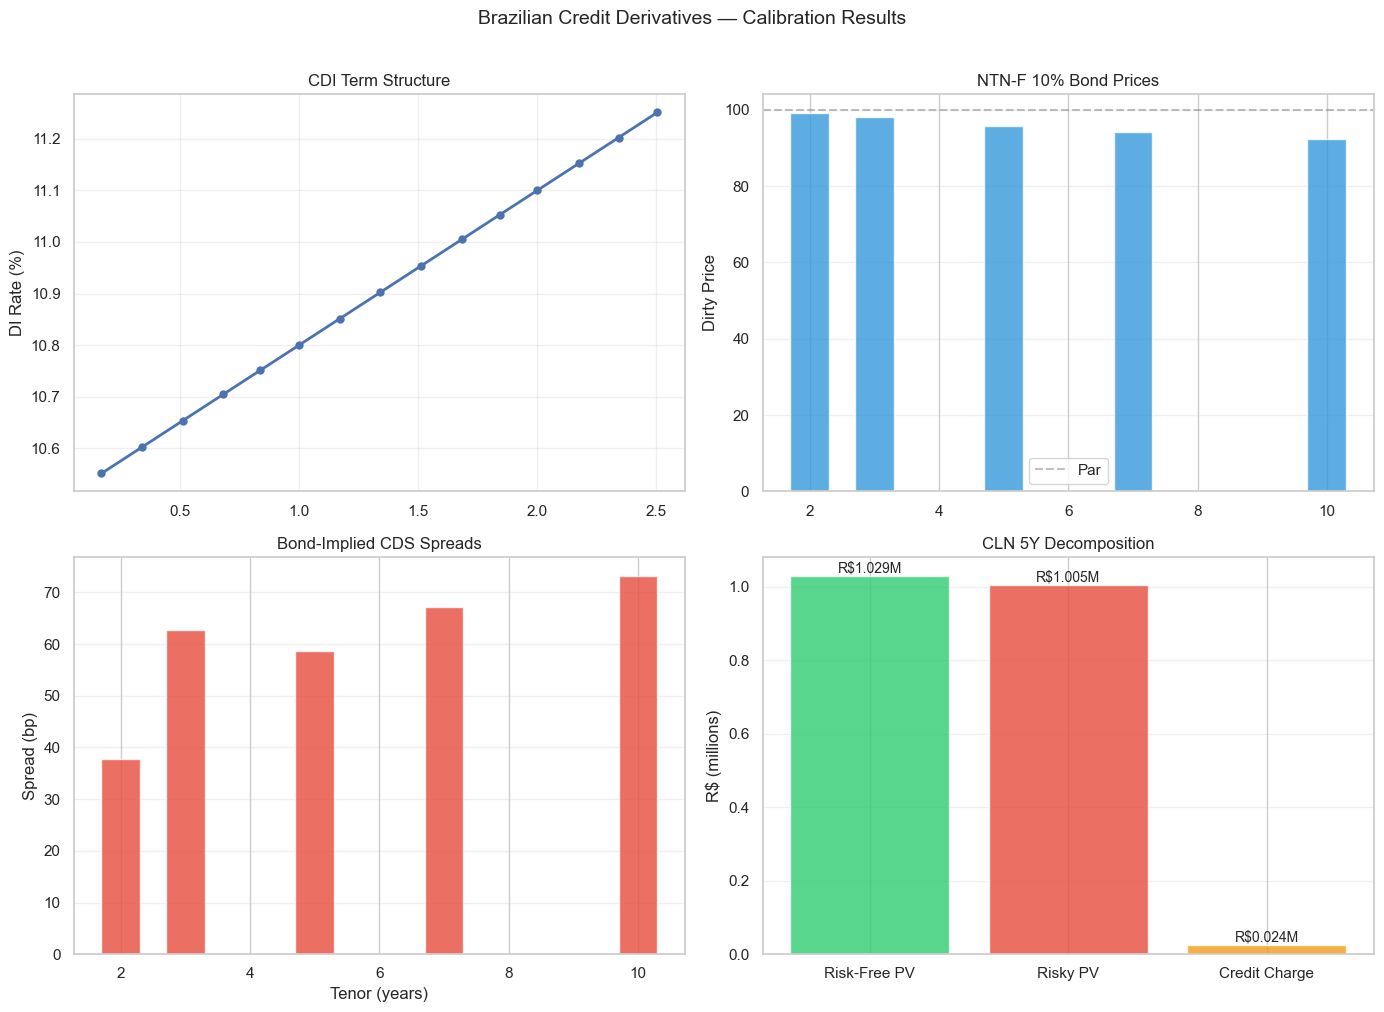

In [13]:
# Summary: all calibrated quantities in one view
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. CDI term structure
ax = axes[0, 0]
years = [c["years"] for c in di_strip]
rates = [c["rate"] * 100 for c in di_strip]
ax.plot(years, rates, 'b-o', linewidth=2, markersize=5)
ax.set_title('CDI Term Structure'); ax.set_ylabel('DI Rate (%)')
ax.grid(True, alpha=0.3)
    
    # 2. NTN-F prices
ax = axes[0, 1]
tenors = list(ntn_f_prices.keys())
prices = list(ntn_f_prices.values())
ax.bar(tenors, prices, color='#3498db', alpha=0.8, width=0.6)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Par')
ax.set_title('NTN-F 10% Bond Prices'); ax.set_ylabel('Dirty Price')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    
    # 3. Implied CDS spreads
ax = axes[1, 0]
imp_tenors = sorted(implied_hazards.keys())
imp_spreads = [(1-0.4) * implied_hazards[t] * 10000 for t in imp_tenors]
ax.bar(imp_tenors, imp_spreads, color='#e74c3c', alpha=0.8, width=0.6)
ax.set_title('Bond-Implied CDS Spreads'); ax.set_ylabel('Spread (bp)')
ax.set_xlabel('Tenor (years)'); ax.grid(True, alpha=0.3, axis='y')
    
    # 4. CLN vs risk-free
ax = axes[1, 1]
labels = ['Risk-Free PV', 'Risky PV', 'Credit Charge']
vals = [cln_riskfree/1e6, cln_risky/1e6, (cln_riskfree-cln_risky)/1e6]
colors = ['#2ecc71', '#e74c3c', '#f39c12']
bars = ax.bar(labels, vals, color=colors, alpha=0.8)
ax.set_title('CLN 5Y Decomposition'); ax.set_ylabel('R$ (millions)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'R${val:.3f}M', ha='center', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
plt.suptitle('Brazilian Credit Derivatives — Calibration Results', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('brazilian_credit_full.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Step | Input | Output | pricebook Module |
|---|---|---|---|
| 1. CDI Curve | DI futures strip | Discount factors | `build_cdi_curve_from_di()` |
| 2. Bond Pricing | NTN-F conventions + CDI curve | Dirty prices | `create_sovereign_bond("NTN_F")` |
| 3. Hazard Rates | Corporate bond prices | Implied CDS spreads | `bond_implied_cds_spread()` |
| 4. CDS Curve | Hazard rates | Survival curve + par spreads | `SurvivalCurve` + `CDS` |
| 5. CLN Pricing | CDI + survival curves | Risky PV, credit charge | `CreditLinkedNote` |
| 6. TRS Pricing | Bond price + funding | TRS PV | `TotalReturnSwap` |

**Key Brazilian conventions:**
- Day count: BUS/252 (business days / 252)
- Compounding: discrete annual $(1+r)^{bd/252}$
- Calendar: São Paulo (Carnival, all holidays)
- CDI: overnight, compounded daily, administered by B3